# Tema 3: Clustering Kabupaten/Kota Aceh Berdasarkan Ketimpangan Negeri vs Swasta

**Skenario 1 — Clustering** | Dataset: `data_bersih.csv`

**Pertanyaan:** Kabupaten mana yang ekosistem pendidikannya didominasi sekolah negeri vs yang punya sektor swasta kuat?

## 1. Import Library

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 20)

print("Library berhasil di-import.")


Library berhasil di-import.


## 2. Load Dataset

In [2]:
df = pd.read_csv('data_bersih.csv')
print("Ukuran data:", df.shape)
print("Jumlah kabupaten/kota:", df['kabupaten_kota'].nunique())
print("Rentang tahun:", df['tahun'].min(), "-", df['tahun'].max())
print("Missing value:", df.isnull().sum().sum())
print("Duplikat:", df.duplicated().sum())
df.head()

Ukuran data: (230, 41)
Jumlah kabupaten/kota: 23
Rentang tahun: 2016 - 2025
Missing value: 0
Duplikat: 0


,kabupaten_kota,tahun,hls__nilai,rls__nilai,amh__nilai,sd__Jumlah Sekolah SD (Negeri),sd__Jumlah Sekolah SD (Swasta),sd__Jumlah Sekolah SD (Negeri+Swasta),sd__Jumlah Guru SD (Negeri),sd__Jumlah Guru SD (Swasta),...,sma__Jumlah Murid SMA (Negeri+Swasta),smk__Jumlah Sekolah SMK (Negeri),smk__Jumlah Sekolah SMK (Swasta),smk__Jumlah Sekolah SMK (Negeri+Swasta),smk__Jumlah Guru SMK (Negeri),smk__Jumlah Guru SMK (Swasta),smk__Jumlah Guru SMK (Negeri+Swasta),smk__Jumlah Murid SMK (Negeri),smk__Jumlah Murid SMK (Swasta),smk__Jumlah Murid SMK (Negeri+Swasta)
0,Kabupaten Aceh Barat,2016,14.56,8.70,97.84,148,4,153,2125,48,...,4974,10,1,11,297,16,313,2469,42,2511
1,Kabupaten Aceh Barat,2017,14.57,9.04,97.84,150,3,153,2050,41,...,5040,10,1,11,296,14,310,2578,26,2604
2,Kabupaten Aceh Barat,2018,14.58,9.08,97.84,150,3,153,2127,36,...,4908,10,1,11,300,15,316,2606,30,2635
3,Kabupaten Aceh Barat,2019,14.59,9.09,97.84,150,3,153,2276,39,...,4941,10,1,11,305,16,321,2633,33,2666
4,Kabupaten Aceh Barat,2020,14.60,9.37,97.84,150,3,153,2367,38,...,4719,10,1,11,312,20,332,2619,66,2685


## 3. Agregasi ke Level Kabupaten/Kota

In [3]:
numeric_cols = df.columns.drop(['kabupaten_kota', 'tahun'])
agg = df.groupby('kabupaten_kota')[numeric_cols].mean().reset_index()
levels = ['sd', 'smp', 'sma', 'smk']
print("Ukuran data setelah agregasi:", agg.shape)
agg.head()

Ukuran data setelah agregasi: (23, 40)


,kabupaten_kota,hls__nilai,rls__nilai,amh__nilai,sd__Jumlah Sekolah SD (Negeri),sd__Jumlah Sekolah SD (Swasta),sd__Jumlah Sekolah SD (Negeri+Swasta),sd__Jumlah Guru SD (Negeri),sd__Jumlah Guru SD (Swasta),sd__Jumlah Guru SD (Negeri+Swasta),...,sma__Jumlah Murid SMA (Negeri+Swasta),smk__Jumlah Sekolah SMK (Negeri),smk__Jumlah Sekolah SMK (Swasta),smk__Jumlah Sekolah SMK (Negeri+Swasta),smk__Jumlah Guru SMK (Negeri),smk__Jumlah Guru SMK (Swasta),smk__Jumlah Guru SMK (Negeri+Swasta),smk__Jumlah Murid SMK (Negeri),smk__Jumlah Murid SMK (Swasta),smk__Jumlah Murid SMK (Negeri+Swasta)
0,Kabupaten Aceh Barat,14.664,9.466,98.080,149.9,4.4,154.4,2190.9,58.7,2263.8,...,4811.6,10.4,0.6,11.0,328.3,9.6,338.0,2680.8,25.2,2705.9
1,Kabupaten Aceh Barat Daya,13.616,8.487,96.099,107.0,3.0,110.0,1502.1,36.5,1533.4,...,4745.6,5.0,0.0,5.0,154.6,0.0,154.6,1105.8,0.0,1105.8
2,Kabupaten Aceh Besar,14.688,10.240,98.490,201.4,11.0,212.5,2496.8,213.3,2710.3,...,8426.9,7.9,2.9,10.8,379.3,32.1,411.4,2852.6,405.6,3258.2
3,Kabupaten Aceh Jaya,13.994,89.089,96.632,98.0,0.0,98.0,1051.8,0.0,1070.8,...,2392.0,6.0,1.0,7.0,114.6,14.4,129.0,717.8,138.7,856.5
4,Kabupaten Aceh Selatan,14.372,8.671,96.996,201.5,3.2,204.9,2568.2,30.8,2586.0,...,6952.2,10.0,1.3,11.3,270.8,13.2,284.1,1449.4,80.2,1529.6


## 4. Feature Engineering

Fitur berupa proporsi (bukan angka mentah) sekolah swasta dan murid swasta terhadap total, per jenjang.

## 4.1. Integrasi Fitur Spasial untuk Spatial K-Means
**Penjelasan Metodologi Analisis Spasial:**
Untuk menjawab kebutuhan **Analisis Spasial (Spatial Analysis)**, algoritma K-Means kini menggunakan matriks fitur terintegrasi yang mencakup **fitur geografis/spasial** (`latitude` dan `longitude`) dari koordinat sentroid masing-masing Kabupaten/Kota di Provinsi Aceh, disamping indikator atribut pendidikan.

Dengan pendekatan **Spatial-Attribute K-Means** ini, pengelompokan yang dihasilkan oleh K-Means memperhitungkan dua dimensi secara simultan:
1. **Kedekatan Lokasi Geografis (Spatial Proximity)**: Memastikan wilayah yang secara geografis berdekatan/bertetangga dipertimbangkan dalam pembentukan klaster.
2. **Kemiripan Indikator Pendidikan (Attribute Similarity)**: Memastikan karakteristik atribut pendidikan (seperti HLS, RLS, AMH, dan rasio-rasio pendidikan) tetap dioptimalkan.


In [4]:
feat = pd.DataFrame()
feat['kabupaten_kota'] = agg['kabupaten_kota']

for lv in levels:

    # Sekolah
    sek_n = agg[f'{lv}__Jumlah Sekolah {lv.upper()} (Negeri)']
    sek_s = agg[f'{lv}__Jumlah Sekolah {lv.upper()} (Swasta)']

    # Murid
    mur_n = agg[f'{lv}__Jumlah Murid {lv.upper()} (Negeri)']
    mur_s = agg[f'{lv}__Jumlah Murid {lv.upper()} (Swasta)']

    # Guru
    guru_n = agg[f'{lv}__Jumlah Guru {lv.upper()} (Negeri)']
    guru_s = agg[f'{lv}__Jumlah Guru {lv.upper()} (Swasta)']

    # ===============================
    # PROPORSI SWASTA
    # ===============================
    feat[f'{lv}_proporsi_sekolah_swasta'] = (
        sek_s / (sek_n + sek_s)
    )

    feat[f'{lv}_proporsi_murid_swasta'] = (
        mur_s / (mur_n + mur_s)
    )

    feat[f'{lv}_proporsi_guru_swasta'] = (
        guru_s / (guru_n + guru_s)
    )

    # ===============================
    # RASIO NEGERI : SWASTA
    # ===============================
    feat[f'{lv}_rasio_sekolah'] = (
        sek_n / (sek_s + 1)
    )

    feat[f'{lv}_rasio_murid'] = (
        mur_n / (mur_s + 1)
    )

    feat[f'{lv}_rasio_guru'] = (
        guru_n / (guru_s + 1)
    )

feat = feat.fillna(0)

print("Ukuran feature:", feat.shape)
feat.head()
# Koordinat Geografis (Spasial) Kabupaten/Kota di Aceh
koordinat_aceh = {
    'Kabupaten Aceh Barat': (4.45, 96.16),
    'Kabupaten Aceh Barat Daya': (3.83, 96.89),
    'Kabupaten Aceh Besar': (5.38, 95.52),
    'Kabupaten Aceh Jaya': (4.72, 95.64),
    'Kabupaten Aceh Selatan': (3.31, 97.18),
    'Kabupaten Aceh Singkil': (2.42, 97.93),
    'Kabupaten Aceh Tengah': (4.54, 96.91),
    'Kabupaten Aceh Tenggara': (3.37, 97.80),
    'Kabupaten Aceh Timur': (4.63, 97.63),
    'Kabupaten Aceh Utara': (4.97, 97.14),
    'Kabupaten Bener Meriah': (4.73, 96.86),
    'Kabupaten Bireuen': (5.14, 96.62),
    'Kabupaten Gayo Lues': (3.96, 97.33),
    'Kabupaten Nagan Raya': (4.16, 96.43),
    'Kabupaten Pidie': (5.16, 95.96),
    'Kabupaten Pidie Jaya': (5.23, 96.22),
    'Kabupaten Simeulue': (2.61, 96.08),
    'Kota Banda Aceh': (5.55, 95.32),
    'Kota Langsa': (4.47, 97.96),
    'Kota Lhokseumawe': (5.18, 97.14),
    'Kota Sabang': (5.88, 95.32),
    'Kota Subulussalam': (2.64, 97.93),
    'Kabupaten Aceh Tamiang': (4.25, 98.02)
}

feat['latitude'] = feat['kabupaten_kota'].map(lambda x: koordinat_aceh.get(x, (0,0))[0])
feat['longitude'] = feat['kabupaten_kota'].map(lambda x: koordinat_aceh.get(x, (0,0))[1])


Ukuran feature: (23, 25)


## 5. Exploratory Data Analysis — Korelasi Antar Fitur

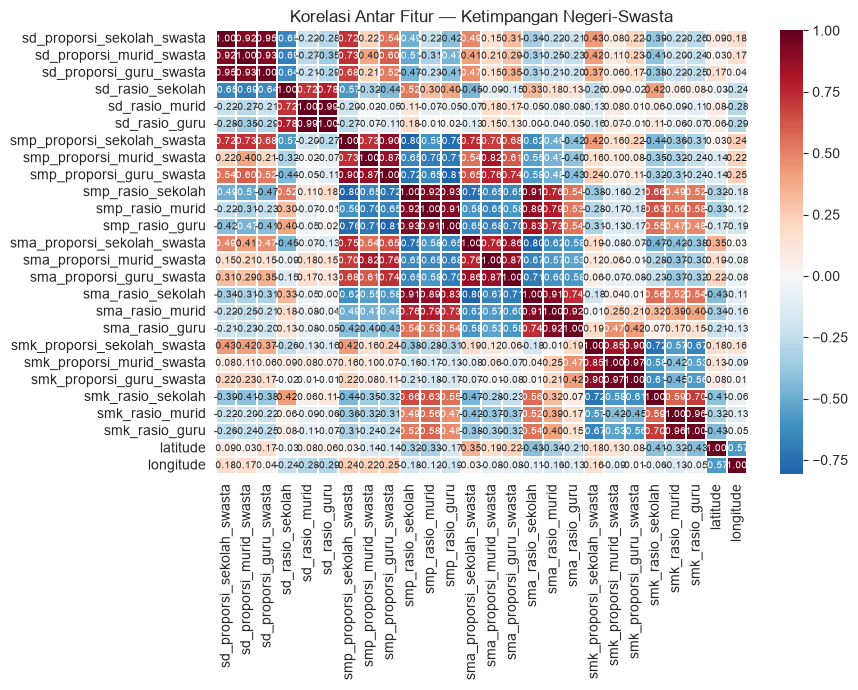

In [5]:

plt.figure(figsize=(9, 7))
corr = feat.drop(columns=['kabupaten_kota']).corr()
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=True, fmt='.2f', linewidths=0.3, annot_kws={'size':7})
plt.title('Korelasi Antar Fitur — Ketimpangan Negeri-Swasta')
plt.tight_layout()
plt.show()


## 6. Standarisasi Fitur

In [6]:

X = feat.drop(columns=['kabupaten_kota'])
X_scaled = StandardScaler().fit_transform(X)
print("Bentuk data setelah standarisasi:", X_scaled.shape)


Bentuk data setelah standarisasi: (23, 26)


## 7. Menentukan Jumlah Cluster Optimal (Elbow Method & Silhouette Score)

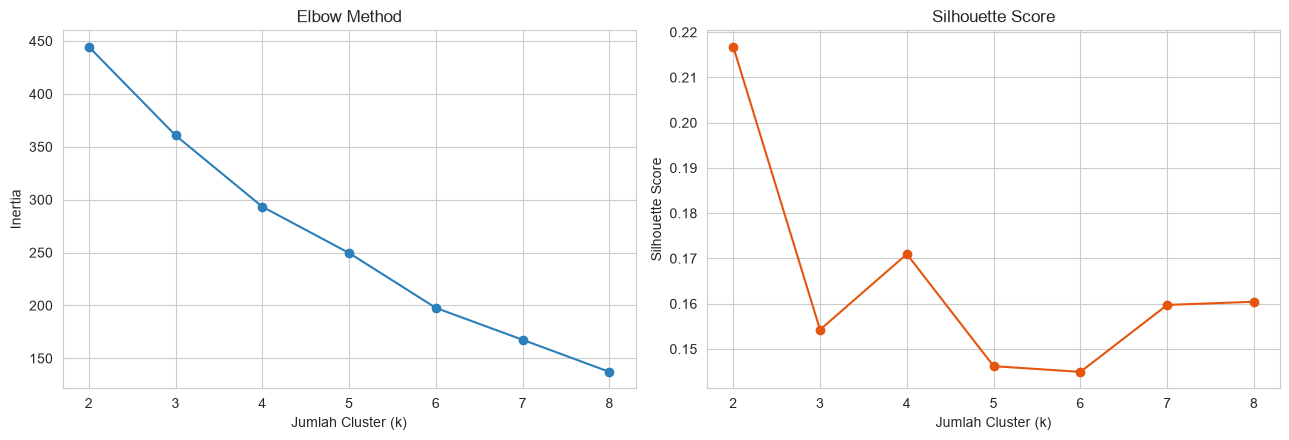

k=2: inertia=444.57, silhouette=0.2168
k=3: inertia=360.78, silhouette=0.1543
k=4: inertia=293.33, silhouette=0.1710
k=5: inertia=249.58, silhouette=0.1462
k=6: inertia=197.71, silhouette=0.1449
k=7: inertia=167.55, silhouette=0.1597
k=8: inertia=137.23, silhouette=0.1604


In [7]:

K_range = range(2, 9)
inertias, sil_scores = [], []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(K_range), inertias, marker='o', color='#2c7fb8')
axes[0].set_xlabel('Jumlah Cluster (k)'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Elbow Method')
axes[1].plot(list(K_range), sil_scores, marker='o', color='#e6550d')
axes[1].set_xlabel('Jumlah Cluster (k)'); axes[1].set_ylabel('Silhouette Score'); axes[1].set_title('Silhouette Score')
plt.tight_layout()
plt.show()

for k, i, s in zip(K_range, inertias, sil_scores):
    print(f"k={k}: inertia={i:.2f}, silhouette={s:.4f}")


## 8. Fit K-Means Final

In [8]:
best_k = K_range[np.argmax(sil_scores)]

print("K terbaik:", best_k)

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

feat['cluster'] = kmeans.fit_predict(X_scaled)

K terbaik: 2


## 9. Visualisasi Cluster dengan PCA (2D)

Variance explained: 57.7 %


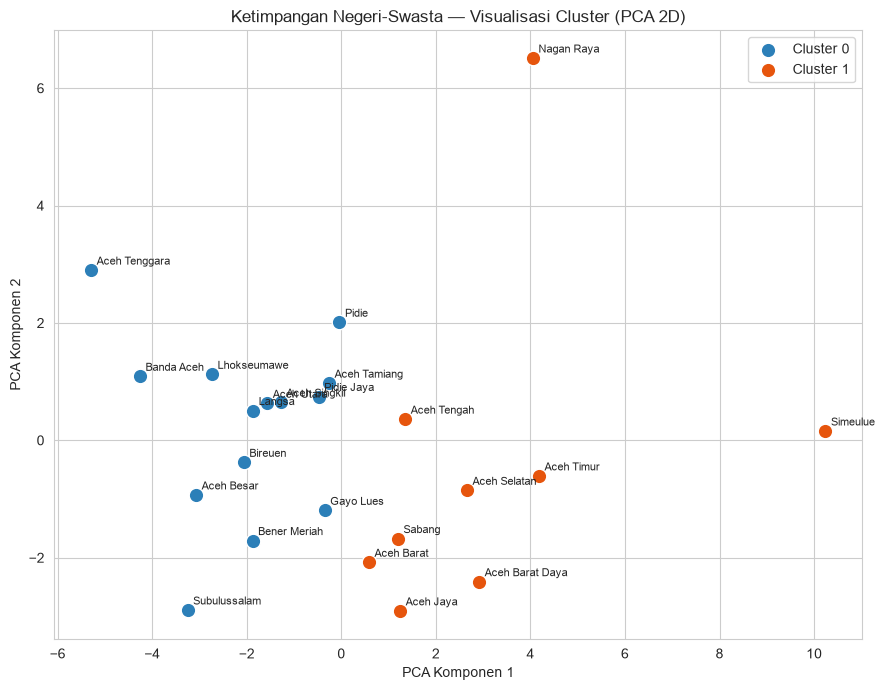

In [9]:

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("Variance explained:", round(pca.explained_variance_ratio_.sum()*100, 1), "%")

plt.figure(figsize=(9, 7))
palette = ['#2c7fb8', '#e6550d', '#31a354', '#756bb1', '#de2d26'][:4]
for c in sorted(feat['cluster'].unique()):
    mask = feat['cluster'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=110, color=palette[c], label=f'Cluster {c}', edgecolor='white')
for i, row in feat.iterrows():
    plt.annotate(row['kabupaten_kota'].replace('Kabupaten ', '').replace('Kota ', ''),
                 (X_pca[i, 0], X_pca[i, 1]), fontsize=8, xytext=(4, 4), textcoords='offset points')
plt.xlabel('PCA Komponen 1'); plt.ylabel('PCA Komponen 2')
plt.title('Ketimpangan Negeri-Swasta — Visualisasi Cluster (PCA 2D)')
plt.legend()
plt.tight_layout()
plt.show()


## 10. Profil Rata-Rata Tiap Cluster

In [10]:

profile = feat.drop(columns=['kabupaten_kota']).groupby('cluster').mean().round(3)
profile

,sd_proporsi_sekolah_swasta,sd_proporsi_murid_swasta,sd_proporsi_guru_swasta,sd_rasio_sekolah,sd_rasio_murid,sd_rasio_guru,smp_proporsi_sekolah_swasta,smp_proporsi_murid_swasta,smp_proporsi_guru_swasta,smp_rasio_sekolah,...,sma_rasio_murid,sma_rasio_guru,smk_proporsi_sekolah_swasta,smk_proporsi_murid_swasta,smk_proporsi_guru_swasta,smk_rasio_sekolah,smk_rasio_murid,smk_rasio_guru,latitude,longitude
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.081,0.088,0.078,17.620,15.460,22.176,0.330,0.239,0.180,2.109,...,6.799,7.796,0.337,0.137,0.126,1.550,34.276,15.411,4.461,96.982
1,0.021,0.031,0.022,41.148,1047.622,163.017,0.138,0.115,0.087,5.986,...,61.611,48.316,0.130,0.083,0.071,4.021,286.051,51.225,4.237,96.471


In [11]:
hasil_cluster = feat.copy()

hasil_cluster.to_csv(
    "hasil_cluster_tema3.csv",
    index=False
)

print("Hasil clustering berhasil disimpan.")

Hasil clustering berhasil disimpan.


## 11. Kesimpulan Analisis

Berdasarkan hasil K-Means (k = 2), kabupaten/kota di Aceh terbagi menjadi dua kelompok berdasarkan komposisi penyelenggaraan pendidikan negeri dan swasta.

- **Cluster 0** memiliki proporsi sekolah, guru, dan murid pada sekolah negeri yang lebih tinggi. Hal ini menunjukkan bahwa penyelenggaraan pendidikan di wilayah tersebut masih didominasi oleh sekolah negeri, sementara kontribusi sekolah swasta relatif lebih kecil.

- **Cluster 1** memiliki proporsi sekolah negeri yang lebih rendah dibandingkan Cluster 0, yang mengindikasikan peran sekolah swasta relatif lebih besar dalam mendukung penyelenggaraan pendidikan di wilayah tersebut.

**Interpretasi utama**

Hasil clustering menunjukkan bahwa terdapat perbedaan tingkat keterlibatan sekolah swasta antarwilayah di Provinsi Aceh. Sebagian besar kabupaten masih didominasi oleh penyelenggaraan pendidikan negeri, sedangkan beberapa wilayah memiliki komposisi yang lebih seimbang antara sekolah negeri dan swasta. Temuan ini dapat menjadi dasar dalam penyusunan kebijakan pembinaan sekolah swasta maupun pemerataan layanan pendidikan sesuai karakteristik masing-masing daerah.